<a href="https://colab.research.google.com/github/jeevadharan24-png/Deep-Learning_24BAD046-/blob/main/Exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

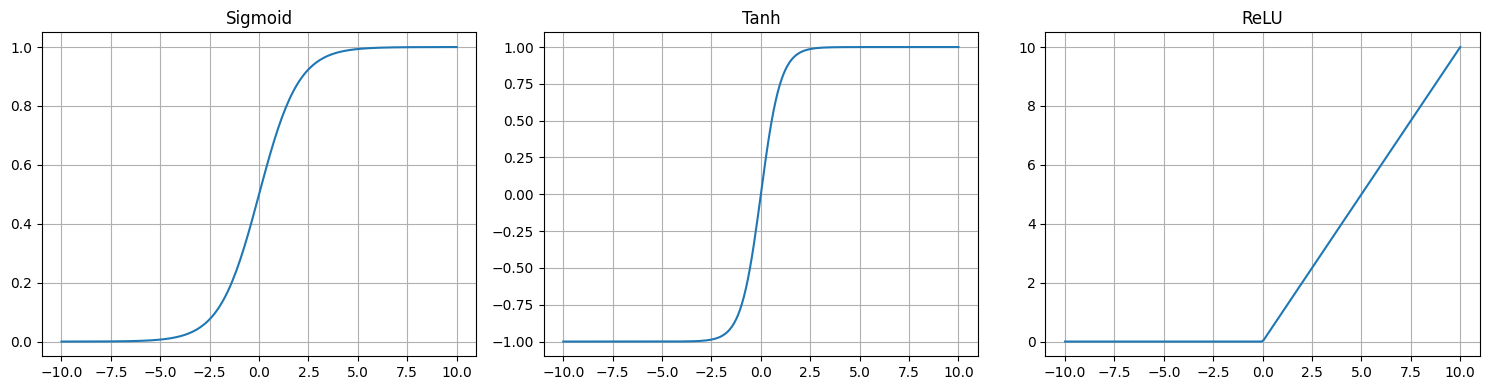

In [1]:
# Student Name : jeevadharan G
# Roll No : 24BAD046

#PART A – Visualization of Activation Functions

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(x, sigmoid)
plt.title("Sigmoid")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(x, tanh)
plt.title("Tanh")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(x, relu)
plt.title("ReLU")
plt.grid(True)

plt.tight_layout()
plt.show()

Training using sigmoid
Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2397 - mae: 0.8516 - val_loss: 0.8061 - val_mae: 0.6804
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6097 - mae: 0.5867 - val_loss: 0.5432 - val_mae: 0.5484
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4755 - mae: 0.5079 - val_loss: 0.4842 - val_mae: 0.5075
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4362 - mae: 0.4795 - val_loss: 0.4659 - val_mae: 0.4743
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4168 - mae: 0.4637 - val_loss: 0.4441 - val_mae: 0.4701
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4045 - mae: 0.4550 - val_loss: 0.4373 - val_mae: 0.4584
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3944 - mae: 0.4474 - val_loss: 0.4330 - val_mae: 0.4775
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3884 - mae: 0.4444 - val_loss: 0.4270 - val_mae: 0.4514
Epoch 9/20
413/413 ━━━━━━━━━━━━━━

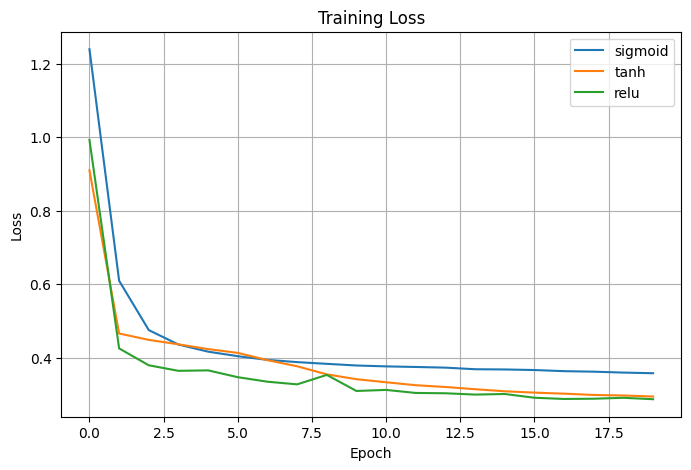

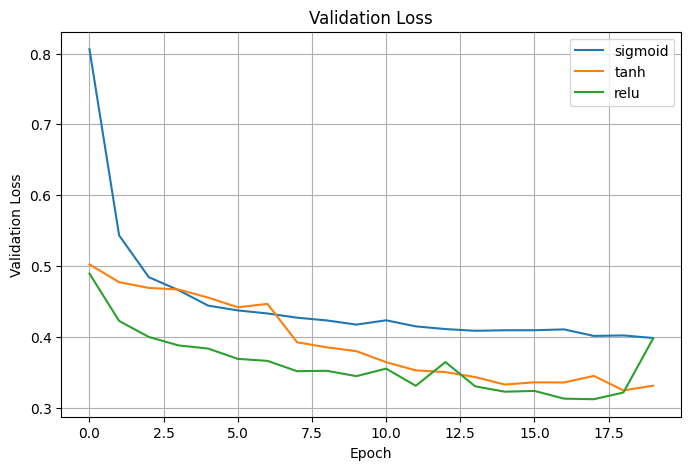


Activation: sigmoid
Training Loss: 0.35812193155288696
Validation Loss: 0.3982894718647003
Training MAE: 0.4270436763763428
Validation MAE: 0.4475194811820984

Activation: tanh
Training Loss: 0.2946929931640625
Validation Loss: 0.3309389054775238
Training MAE: 0.37607958912849426
Validation MAE: 0.39879727363586426

Activation: relu
Training Loss: 0.2873932421207428
Validation Loss: 0.39758676290512085
Training MAE: 0.3696102499961853
Validation MAE: 0.41387099027633667


In [2]:
# PART B – Performance Comparison of Activation Functions

import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset
data = fetch_california_housing()

X = data.data
y = data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create Model
def create_model(activation):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(8,)),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(32, activation=activation),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

activations = ['sigmoid', 'tanh', 'relu']

history = {}

for act in activations:

    print("Training using", act)

    model = create_model(act)

    hist = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=1
    )

    history[act] = hist

# Training Loss
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(history[act].history['loss'], label=act)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Validation Loss
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(history[act].history['val_loss'], label=act)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Final Results
for act in activations:

    print("\nActivation:", act)

    print("Training Loss:", history[act].history['loss'][-1])

    print("Validation Loss:", history[act].history['val_loss'][-1])

    print("Training MAE:", history[act].history['mae'][-1])

    print("Validation MAE:", history[act].history['val_mae'][-1])


Training using SGD
Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7028 - mae: 0.5885 - val_loss: 0.5060 - val_mae: 0.5202
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4613 - mae: 0.4873 - val_loss: 0.4594 - val_mae: 0.4886
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4225 - mae: 0.4666 - val_loss: 0.4390 - val_mae: 0.4704
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4046 - mae: 0.4547 - val_loss: 0.4272 - val_mae: 0.4694
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3907 - mae: 0.4456 - val_loss: 0.4185 - val_mae: 0.4502
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3796 - mae: 0.4375 - val_loss: 0.4383 - val_mae: 0.4883
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3710 - mae: 0.4324 - val_loss: 0.3965 - val_mae: 0.4391
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3634 - mae: 0.4262 - val_loss: 0.4124 - val_mae: 0.4659
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━

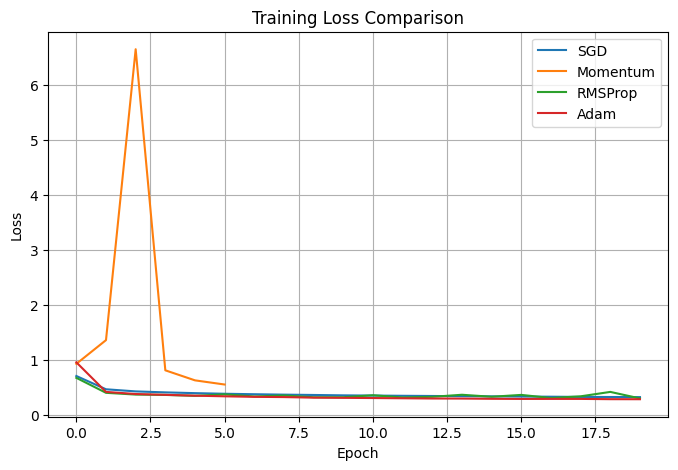

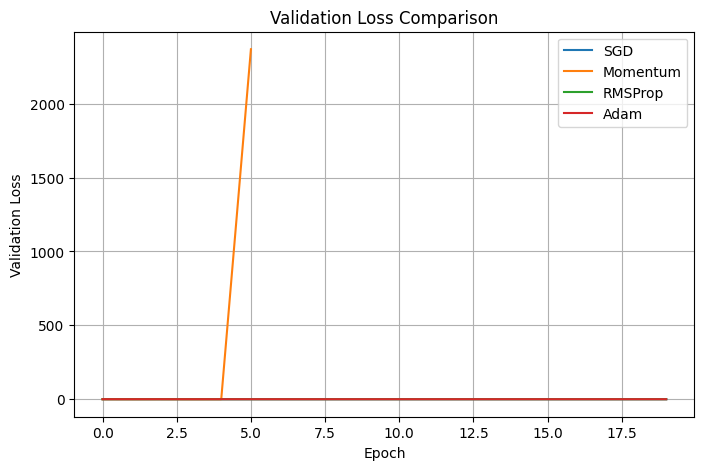


Final Comparison

Optimizer: SGD
Training Loss: 0.31832221150398254
Validation Loss: 0.34338122606277466
Training MAE: 0.3947930335998535
Validation MAE: 0.4081954061985016

Optimizer: Momentum
Training Loss: nan
Validation Loss: nan
Training MAE: nan
Validation MAE: nan

Optimizer: RMSProp
Training Loss: 0.294668972492218
Validation Loss: 0.3192216157913208
Training MAE: 0.36977875232696533
Validation MAE: 0.4013473689556122

Optimizer: Adam
Training Loss: 0.2801276743412018
Validation Loss: 0.3181147277355194
Training MAE: 0.36490848660469055
Validation MAE: 0.37274932861328125


In [3]:
# PART C – Comparison of Optimization Algorithms

import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset
data = fetch_california_housing()

X = data.data
y = data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create Model
def create_model(optimizer):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(8,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

optimizers = {

    "SGD": tf.keras.optimizers.SGD(),

    "Momentum": tf.keras.optimizers.SGD(momentum=0.9),

    "RMSProp": tf.keras.optimizers.RMSprop(),

    "Adam": tf.keras.optimizers.Adam()

}

history = {}

for name, opt in optimizers.items():

    print("\nTraining using", name)

    model = create_model(opt)

    hist = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=1
    )

    history[name] = hist

# Training Loss
plt.figure(figsize=(8,5))

for name in history:
    plt.plot(history[name].history['loss'], label=name)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Validation Loss
plt.figure(figsize=(8,5))

for name in history:
    plt.plot(history[name].history['val_loss'], label=name)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Final Results
print("\nFinal Comparison")

for name in history:

    print("\nOptimizer:", name)

    print("Training Loss:", history[name].history['loss'][-1])

    print("Validation Loss:", history[name].history['val_loss'][-1])

    print("Training MAE:", history[name].history['mae'][-1])

    print("Validation MAE:", history[name].history['val_mae'][-1])

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
model.save('/content/drive/MyDrive/ANN_Model.keras')
print("Model Saved Successfully")

Model Saved Successfully


In [8]:
from tensorflow.keras.models import load_model

loaded_model = load_model('/content/drive/MyDrive/ANN_Model.keras')
print("Model Loaded Successfully")

Model Loaded Successfully


In [9]:
content = """
# Deep Learning Lab

Experiment 2

Name : Jeevadharan G
Roll No : 24BAD046
"""

with open("README.md", "w") as f:
    f.write(content)

print("README.md Created Successfully")

README.md Created Successfully
